# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [2]:
# Load data
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

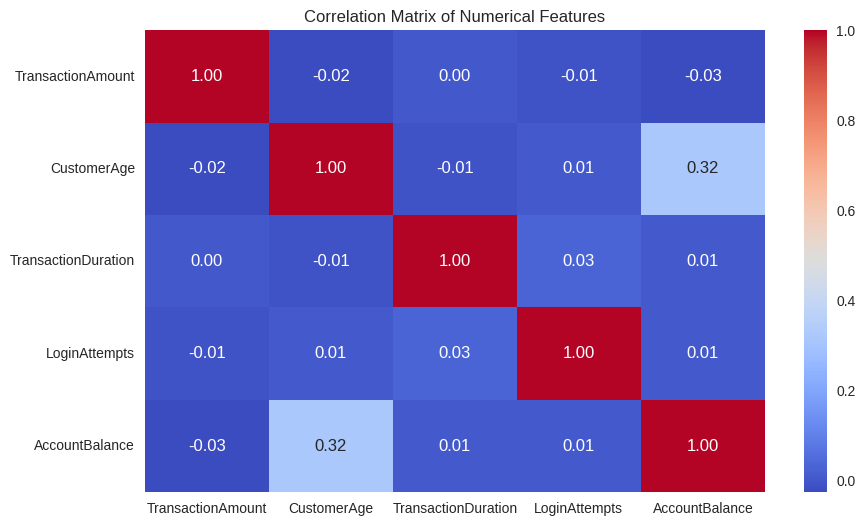

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

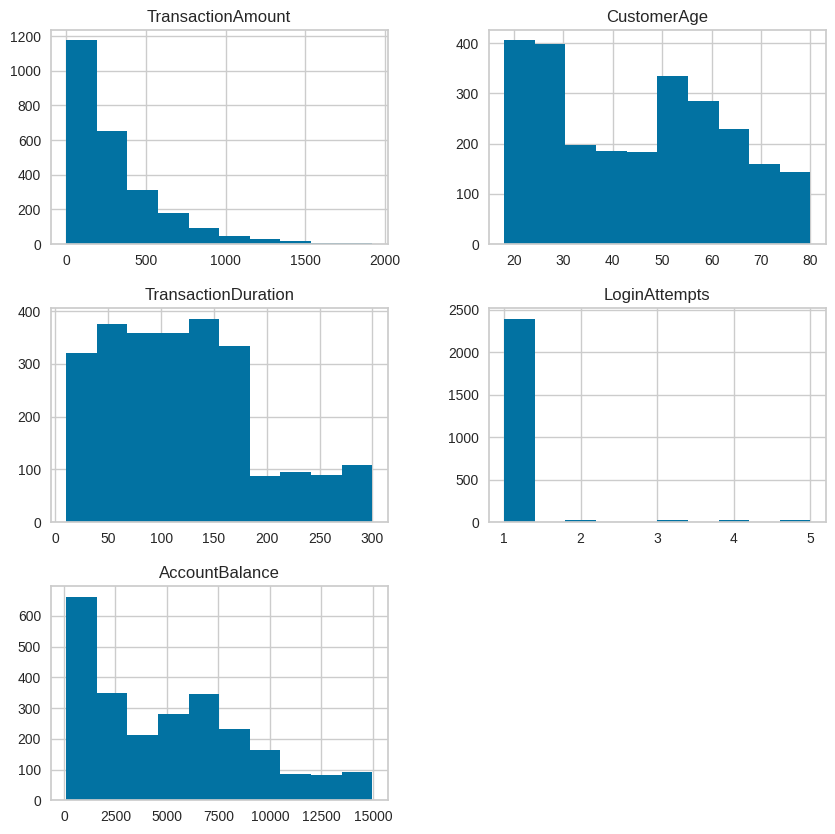

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
df.hist(figsize=(10, 10))
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

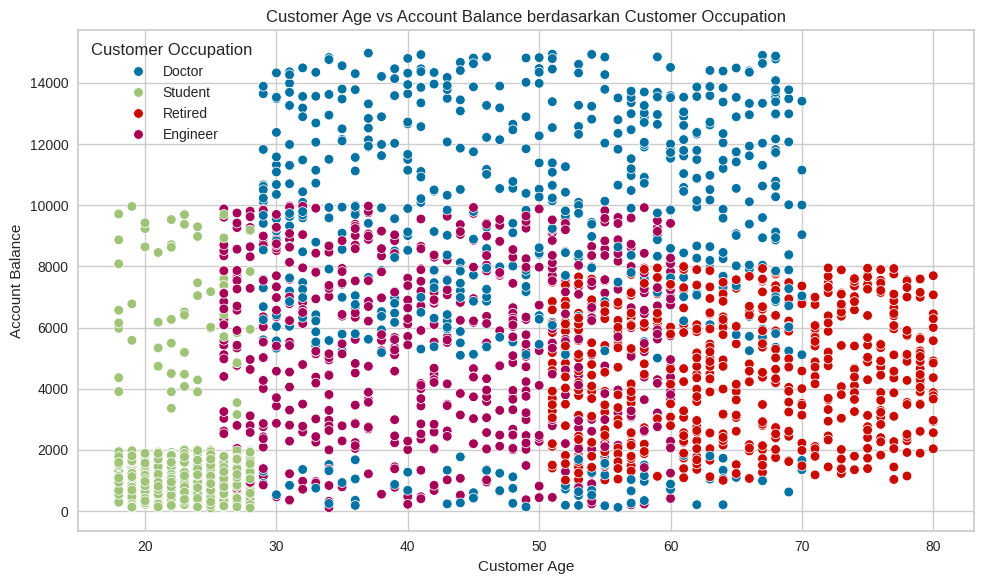

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CustomerAge', y='AccountBalance', hue='CustomerOccupation', data=df)
plt.title('Customer Age vs Account Balance berdasarkan Customer Occupation')
plt.xlabel('Customer Age')
plt.ylabel('Account Balance')
plt.legend(title='Customer Occupation')
plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [9]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [10]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [11]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.
scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('CustomerAge') #dikecualikan karna mau dibinning nantinya
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,0.007207,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,0.244828,0.0,0.336832,2024-11-04 08:08:08
1,TX000002,AC00455,0.195940,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,0.451724,0.0,0.918055,2024-11-04 08:09:35
2,TX000003,AC00019,0.065680,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,0.158621,0.0,0.068637,2024-11-04 08:07:04
3,TX000004,AC00070,0.096016,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,0.051724,0.0,0.569198,2024-11-04 08:09:06
4,TX000005,AC00411,0.006874,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,0.648276,0.0,0.492591,2024-11-04 08:06:39


In [12]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df = df.drop(columns=['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'TransactionDate', 'PreviousTransactionDate'])

In [13]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.
categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,0.007207,1,36,0,70.0,0,0.244828,0.0,0.336832
1,0.195940,1,15,0,68.0,0,0.451724,0.0,0.918055
2,0.065680,1,23,2,19.0,3,0.158621,0.0,0.068637
3,0.096016,1,33,2,26.0,3,0.051724,0.0,0.569198
4,0.006874,0,1,2,NaN,3,0.648276,0.0,0.492591


In [14]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [15]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
df = df.fillna(df.median())
df.isnull().sum()

,0
TransactionAmount,0
TransactionType,0
Location,0
Channel,0
CustomerAge,0
CustomerOccupation,0
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


In [16]:
# Menghapus data duplikat menggunakan drop_duplicates().
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [17]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.

# Fungsi untuk menghandle outlier dengan mengganti nilai outlier dengan nilai Q1 atau Q3
print("Jumlah baris sebelum penanganan outlier:", df.shape)
def handle_outliers(data, numeric_cols):
    for column in numeric_cols:
        Q1 = np.percentile(data[column], 25)
        Q3 = np.percentile(data[column], 75)
        IQR = Q3 - Q1

        # Batas bawah dan atas untuk mendeteksi outlier
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        # Mengganti nilai outlier yang lebih kecil dari lower_bound dengan nilai lower_bound
        data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
        # Mengganti nilai outlier yang lebih besar dari upper_bound dengan nilai upper_bound
        data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])

# Menjalankan fungsi handle_outliers untuk data dan kolom numerik
handle_outliers(df, numeric_cols)
print("Jumlah baris setelah penanganan outlier:", df.shape)

Jumlah baris sebelum penanganan outlier: (2513, 9)
Jumlah baris setelah penanganan outlier: (2513, 9)


In [18]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

df['CustomerAge'] = pd.cut(
    df['CustomerAge'],
    bins=3,
    labels=['Youth', 'Adult', 'Senior'])
if 'CustomerAge' not in categorical_cols:
    categorical_cols.append('CustomerAge')

#Label Encoder
le_age = LabelEncoder()
df['CustomerAge'] = le_age.fit_transform(df['CustomerAge'].astype(str))
encoders['CustomerAge'] = le_age
df.head()


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,0.007207,1,36,0,1,0,0.244828,0.0,0.336832
1,0.195940,1,15,0,1,0,0.451724,0.0,0.918055
2,0.065680,1,23,2,2,3,0.158621,0.0,0.068637
3,0.096016,1,33,2,2,3,0.051724,0.0,0.569198
4,0.006874,0,1,2,0,3,0.648276,0.0,0.492591


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [19]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.0,2513.000000
mean,0.147674,0.788301,21.276562,1.010744,1.073219,1.529646,0.377539,0.0,0.336969
std,0.130094,0.436846,12.394375,0.831005,0.867983,1.150333,0.240191,0.0,0.260682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.043203,1.000000,11.000000,0.000000,0.000000,0.000000,0.182759,0.0,0.095325
50%,0.110014,1.000000,21.000000,1.000000,1.000000,2.000000,0.351724,0.0,0.311416
75%,0.213331,1.000000,32.000000,2.000000,2.000000,3.000000,0.520690,0.0,0.506899
max,0.468523,2.000000,43.000000,3.000000,2.000000,4.000000,1.000000,0.0,1.000000


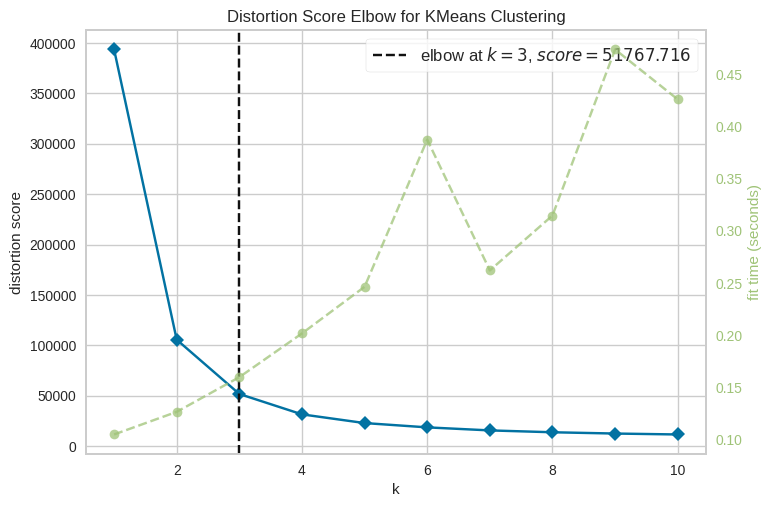

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
kmeans = KMeans(random_state=42, n_init=50)
visualizer = KElbowVisualizer(kmeans, k=(1,11))
visualizer.fit(df)
visualizer.show()

In [21]:
# Menggunakan algoritma K-Means Clustering
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=50)
kmeans_model.fit(df)

KMeans(n_clusters=3, n_init=50, random_state=42)

Jalankan cell code ini untuk menyimpan model kamu.

In [22]:
# Menyimpan model menggunakan joblib
#import joblib
joblib.dump(kmeans_model, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.
silhouette_score = silhouette_score(df, kmeans_model.labels_)
print(f"Silhouette Score: {silhouette_score}")

Silhouette Score: 0.5310606054296031


/tmp/ipython-input-3649458754.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', 3)


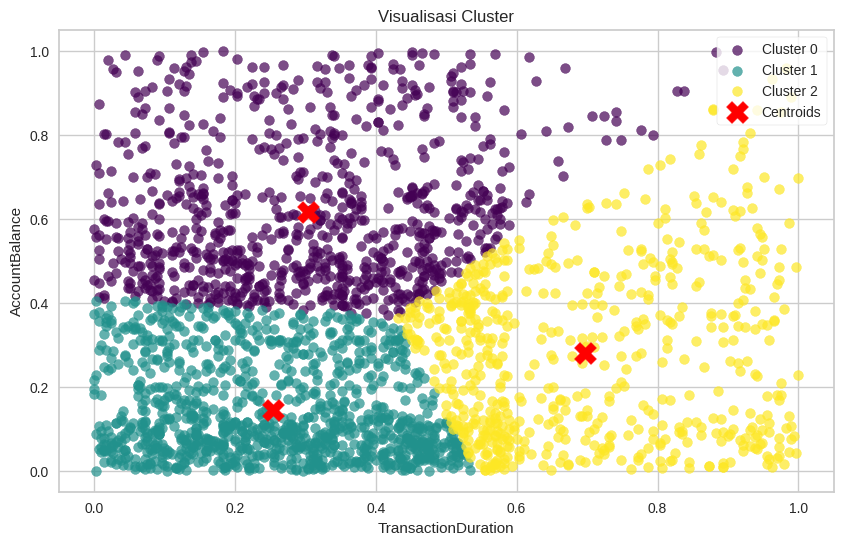

In [24]:
# Membuat visualisasi hasil clustering
sumbu_x = 'TransactionDuration'
sumbu_y = 'AccountBalance'
features = df[[sumbu_x, sumbu_y]].values

# Latih ulang KMeans
kmeans_visual = KMeans(n_clusters=3, random_state=42, n_init=50)
labels_visual = kmeans_visual.fit_predict(features)

# Membuat scatter plot
plt.figure(figsize=(10, 6))
cmap = plt.cm.get_cmap('viridis', 3)
for cluster in range(3):
    plt.scatter(
        df[sumbu_x][labels_visual == cluster],
        df[sumbu_y][labels_visual == cluster],
        color=cmap(cluster),
        s=50,
        alpha=0.7,
        label=f'Cluster {cluster}'
    )
# Centroid
centroids = kmeans_visual.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red', s=250,
    marker='X',
    label='Centroids')

plt.title('Visualisasi Cluster')
plt.xlabel(sumbu_x)
plt.ylabel(sumbu_y)
plt.legend(frameon=True)
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [25]:
# Membangun model menggunakan PCA.
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
PCA_2 = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
kmeans_pca_model = KMeans(n_clusters=3, random_state=42, n_init=50)
kmeans_pca_model.fit(PCA_2)

KMeans(n_clusters=3, n_init=50, random_state=42)

In [26]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(kmeans_pca_model, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [27]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

df['Cluster'] = kmeans_model.labels_

numerical_cols = ['TransactionAmount', 'TransactionDuration', 'AccountBalance']

cluster_desc = df.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).T
cluster_desc



Cluster                          0         1         2
TransactionAmount   mean  0.149872  0.145646  0.147582
                    min   0.000599  0.000031  0.000000
                    max   0.468523  0.468523  0.468523
TransactionDuration mean  0.373088  0.378702  0.380747
                    min   0.000000  0.000000  0.000000
                    max   0.986207  1.000000  1.000000
AccountBalance      mean  0.337050  0.340113  0.333657
                    min   0.000000  0.001125  0.000774
                    max   1.000000  0.997633  0.993532

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
**1. Cluster 0: Transaksi Tinggi & Cepat**
* **Rata-rata (mean) Account Balance:** 0.337050
* **Rata-rata (mean) Transaction Amount:** 0.149872
* **Rata-rata (mean) Transaction Duration:** 0.373088

**Analisis:**
Cluster ini memiliki saldo rekening yang moderat, namun ciri utamanya adalah **nilai transaksi rata-rata paling tinggi** yang diselesaikan dengan **durasi paling cepat**. Profil ini menunjukkan segmen nasabah yang efisien, aktif bertransaksi dengan nilai besar, dan sudah sangat terbiasa dengan platform. **Rekomendasi:** Menawarkan layanan prioritas, promosi *cashback* untuk transaksi bernilai tinggi, atau memperkenalkan fitur-fitur canggih yang dapat lebih mempercepat proses transaksi mereka.

**2. Cluster 1: Penyimpan Dana (Savers)**
* **Rata-rata (mean) Account Balance:** 0.340113
* **Rata-rata (mean) Transaction Amount:** 0.145646
* **Rata-rata (mean) Transaction Duration:** 0.378702

**Analisis:**
Ciri khas cluster ini adalah kepemilikan **saldo rekening rata-rata tertinggi**, namun di sisi lain memiliki **nilai transaksi rata-rata paling rendah**. Ini mengindikasikan profil "penyimpan" (*saver*) yang lebih fokus pada akumulasi dana daripada membelanjakannya. **Rekomendasi:** Menawarkan produk investasi atau tabungan berjangka dengan imbal hasil menarik, layanan perencanaan keuangan, atau fitur di aplikasi yang membantu mereka memantau pertumbuhan dana.

**3. Cluster 2: Hati-hati & Saldo Rendah**
* **Rata-rata (mean) Account Balance:** 0.333657
* **Rata-rata (mean) Transaction Amount:** 0.147582
* **Rata-rata (mean) Transaction Duration:** 0.380747

**Analisis:**
Cluster ini merupakan segmen dengan **saldo rekening rata-rata terendah**. Meskipun nilai transaksinya moderat, mereka membutuhkan **waktu transaksi paling lama**. Hal ini bisa menandakan nasabah yang lebih berhati-hati, pengguna baru yang masih mempelajari platform, atau melakukan transaksi yang lebih kompleks. **Rekomendasi:** Fokus pada peningkatan pengalaman pengguna (UX) untuk membangun kepercayaan, menyediakan panduan atau tutorial yang jelas, serta menawarkan produk perbankan dasar yang mudah diakses dan dipahami.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [28]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df = df.rename(columns={'Cluster': 'Target'})

In [29]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [30]:
# inverse dataset ke rentang normal untuk numerikal
df[numeric_cols] = scaler.inverse_transform(df[numeric_cols])
# tampilkan dataset yang sudah di-inverse
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,14.09,1,36,0,1,0,81.0,1.0,5112.21,0
1,376.24,1,15,0,1,0,141.0,1.0,13758.91,2
2,126.29,1,23,2,2,3,56.0,1.0,1122.35,2
3,184.50,1,33,2,2,3,25.0,1.0,8569.06,0
4,13.45,0,1,2,0,3,198.0,1.0,7429.40,1


In [31]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
for col, le in encoders.items():
    df[col] = le.inverse_transform(df[col])
# tampilkan dataset yang sudah di-inverse
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,14.09,Debit,San Diego,ATM,Senior,Doctor,81.0,1.0,5112.21,0
1,376.24,Debit,Houston,ATM,Senior,Doctor,141.0,1.0,13758.91,2
2,126.29,Debit,Mesa,Online,Youth,Student,56.0,1.0,1122.35,2
3,184.50,Debit,Raleigh,Online,Youth,Student,25.0,1.0,8569.06,0
4,13.45,Credit,Atlanta,Online,Adult,Student,198.0,1.0,7429.40,1


In [32]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Target' in numerical_cols:
    numerical_cols.remove('Target')

# Agregat untuk numerik
numeric_desc = df.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).T

# Agregat untuk Kategorik
categoric_desc = df.groupby('Target')[categorical_cols].agg(lambda x: x.mode().tolist()).T

# Combine
print("Numerical Feature Description:")
display(numeric_desc)

print("\nCategorical Feature Description (Mode):")
display(categoric_desc)

Numerical Feature Description:


Target                               0             1             2
TransactionAmount   mean    287.842609    279.733721    283.448475
                    min       1.410000      0.320000      0.260000
                    max     899.285000    899.285000    899.285000
TransactionDuration mean    118.195388    119.823598    120.416567
                    min      10.000000     10.000000     10.000000
                    max     296.000000    300.000000    300.000000
LoginAttempts       mean      1.000000      1.000000      1.000000
                    min       1.000000      1.000000      1.000000
                    max       1.000000      1.000000      1.000000
AccountBalance      mean   5115.456711   5161.017488   5064.980192
                    min     101.250000    117.980000    112.760000
                    max   14977.990000  14942.780000  14881.770000


Categorical Feature Description (Mode):


Target,0,1,2
TransactionType,[Debit],[Debit],[Debit]
Location,"[Philadelphia, Tucson]",[Fort Worth],[Los Angeles]
Channel,[Branch],[Branch],[Branch]
CustomerAge,[Youth],[Youth],[Youth]
CustomerOccupation,[Student],[Student],[Engineer]


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.

**1. Cluster 0: Efisien & Transaksi Tinggi**
* **Rata-rata (mean) TransactionAmount:** 287.84
* **Rata-rata (mean) TransactionDuration:** 118.19
* **Rata-rata (mean) LoginAttempts:** 1.00
* **Rata-rata (mean) AccountBalance:** 5115.45
* **TransactionType (modus):** [Debit]
* **Location (modus):** [Philadelphia, Tucson]
* **Channel (modus):** [Branch]
* **CustomerAge (modus):** [Youth]
* **CustomerOccupation (modus):** [Student]

**Analisis:**
Cluster ini didominasi oleh nasabah usia muda (**Youth**) dengan pekerjaan **mahasiswa** (*Student*) yang tersebar di **Philadelphia** dan **Tucson**. Mereka secara konsisten bertransaksi menggunakan **Debit** melalui kanal **Cabang** (*Branch*). Ciri utama mereka adalah nilai transaksi rata-rata **tertinggi** yang diselesaikan dalam waktu **tercepat**. Profil ini menunjukkan segmen mahasiswa yang aktif secara finansial, efisien, dan masih mengandalkan layanan cabang untuk transaksinya. **Rekomendasi:** Menawarkan promosi yang relevan dengan gaya hidup mahasiswa aktif, seperti *cashback* untuk kategori belanja populer (gadget, buku), diskon pada layanan digital (streaming, transportasi online), atau mengedukasi mereka tentang fitur digital banking yang bisa melengkapi kebiasaan mereka bertransaksi di cabang.

**2. Cluster 1: Penyimpan Dana**
* **Rata-rata (mean) TransactionAmount:** 279.73
* **Rata-rata (mean) TransactionDuration:** 119.82
* **Rata-rata (mean) LoginAttempts:** 1.00
* **Rata-rata (mean) AccountBalance:** 5161.01
* **TransactionType (modus):** [Debit]
* **Location (modus):** [Fort Worth]
* **Channel (modus):** [Branch]
* **CustomerAge (modus):** [Youth]
* **CustomerOccupation (modus):** [Student]

**Analisis:**
Cluster ini juga didominasi oleh **mahasiswa** dari kalangan usia muda (**Youth**) yang bertransaksi via **Debit** di **Cabang**, namun sangat terkonsentrasi di **Fort Worth**. Karakteristik unik mereka adalah memiliki saldo rekening rata-rata **tertinggi** namun nilai per transaksinya **paling rendah**. Ini mengindikasikan profil "penyimpan" (*saver*) yang lebih fokus pada akumulasi dana daripada membelanjakannya dalam jumlah besar per transaksi. **Rekomendasi:** Menawarkan produk yang mendorong kebiasaan menabung, seperti tabungan berjangka dengan bunga kompetitif, program investasi risiko rendah untuk pemula, atau fitur *goal setting* di aplikasi mobile banking. Kemitraan dengan bisnis lokal di area Fort Worth bisa sangat efektif untuk segmen yang terkonsentrasi ini.

**3. Cluster 2: Nasabah yang Hati-hati**
* **Rata-rata (mean) TransactionAmount:** 283.44
* **Rata-rata (mean) TransactionDuration:** 120.41
* **Rata-rata (mean) LoginAttempts:** 1.00
* **Rata-rata (mean) AccountBalance:** 5064.98
* **TransactionType (modus):** [Debit]
* **Location (modus):** [Los Angeles]
* **Channel (modus):** [Branch]
* **CustomerAge (modus):** [Youth]
* **CustomerOccupation (modus):** [Engineer]

**Analisis:**
Cluster ini memiliki profil yang sangat berbeda, didominasi oleh **insinyur** (*Engineer*) dari kelompok usia muda (**Youth**) yang berlokasi di **Los Angeles**. Seperti cluster lain, mereka juga cenderung menggunakan **Debit** di **Cabang**. Mereka memiliki saldo rata-rata **terendah** dan membutuhkan waktu transaksi **paling lama**. Durasi transaksi yang lama ini mungkin menandakan mereka lebih teliti dan berhati-hati dalam bertransaksi, atau melakukan jenis transaksi yang lebih kompleks di cabang. **Rekomendasi:** Menawarkan produk yang sesuai untuk kalangan profesional muda, seperti program cicilan (KPR atau kendaraan), produk investasi jangka panjang (reksa dana), atau layanan perbankan premium yang menawarkan keamanan dan kemudahan untuk mendukung gaya hidup yang sibuk, baik secara digital maupun di cabang.

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [33]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,14.09,Debit,San Diego,ATM,Senior,Doctor,81.0,1.0,5112.21,0
1,376.24,Debit,Houston,ATM,Senior,Doctor,141.0,1.0,13758.91,2
2,126.29,Debit,Mesa,Online,Youth,Student,56.0,1.0,1122.35,2
3,184.50,Debit,Raleigh,Online,Youth,Student,25.0,1.0,8569.06,0
4,13.45,Credit,Atlanta,Online,Adult,Student,198.0,1.0,7429.40,1


In [34]:
# Simpan Data
df.to_csv('data_clustering_inverse.csv', index=False)

End of Code.